In [1]:
import pandas as pd
from prophet import Prophet

In [2]:
orders = pd.read_csv("../data/processed/orders_clean.csv")

orders["order_time"] = pd.to_datetime(orders["order_time"])

In [3]:
daily_sales = orders.groupby(

    orders["order_time"].dt.date

)["total_usd"].sum().reset_index()

daily_sales.columns = ["ds", "y"]

daily_sales["ds"] = pd.to_datetime(daily_sales["ds"])

In [4]:
model = Prophet()

model.fit(daily_sales)

15:07:31 - cmdstanpy - INFO - Chain [1] start processing
15:07:31 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

In [6]:
forecast[["ds", "yhat"]].to_csv(

    "sales_forecast.csv",
    index=False

)

print("Sales forecast generated")

Sales forecast generated


# Part B — Customer Segmentation
---


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [8]:
orders = pd.read_csv("../data/processed/orders_clean.csv")

orders["order_time"] = pd.to_datetime(orders["order_time"])

orders.head()

,order_id,customer_id,order_time,payment_method,discount_pct,subtotal_usd,total_usd,country,device,source
0,26505,16126,2020-01-01 01:10:58,card,10,372.76,335.48,US,desktop,organic
1,15890,7971,2020-01-01 02:42:36,paypal,20,108.37,86.70,ES,desktop,organic
2,1430,7620,2020-01-01 03:02:43,wallet,5,119.56,113.58,AE,tablet,social
3,25245,7029,2020-01-01 03:15:22,card,0,39.27,39.27,FR,mobile,organic
4,4559,6790,2020-01-01 05:00:52,cod,5,71.27,67.71,US,mobile,organic


In [9]:
reference_date = orders["order_time"].max() + pd.Timedelta(days=1)

In [10]:
rfm = orders.groupby("customer_id").agg({

    "order_time": lambda x: (reference_date - x.max()).days,
    "order_id": "count",
    "total_usd": "sum"

}).reset_index()

rfm.columns = ["customer_id", "recency", "frequency", "monetary"]

rfm.head()

,customer_id,recency,frequency,monetary
0,1,129,2,115.39
1,2,303,2,68.52
2,3,1946,1,66.72
3,4,823,2,279.86
4,5,275,3,271.29


In [11]:
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])

In [12]:
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])

In [13]:
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])

In [14]:
rfm["RFM_score"] = (

    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)

)

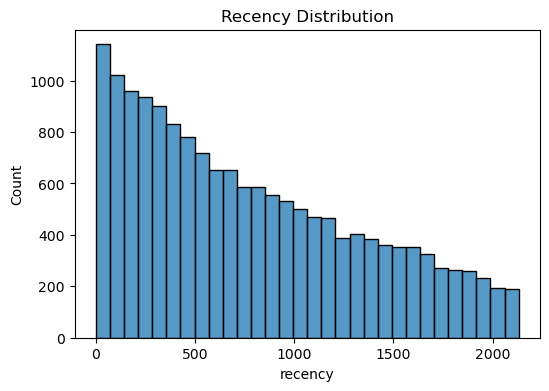

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(rfm["recency"], bins=30)
plt.title("Recency Distribution")
plt.show()

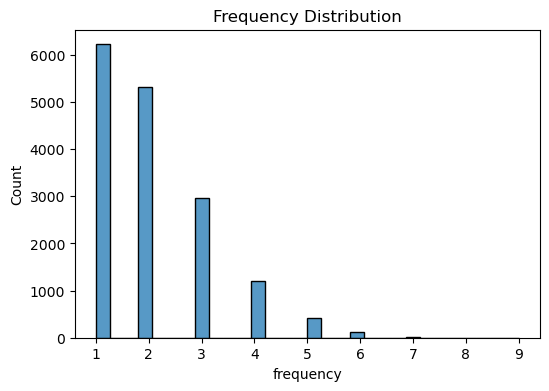

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(rfm["frequency"], bins=30)
plt.title("Frequency Distribution")
plt.show()

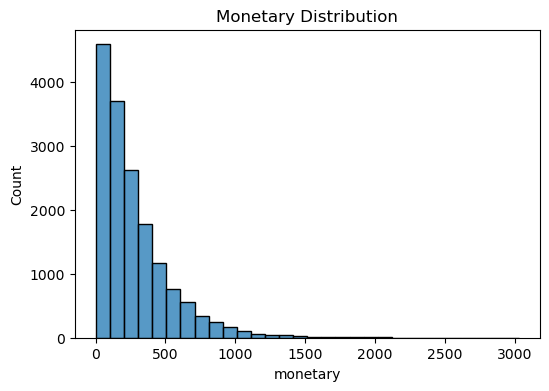

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(rfm["monetary"], bins=30)
plt.title("Monetary Distribution")
plt.show()

In [18]:
rfm_cluster = rfm[["recency","frequency","monetary"]]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_cluster)

In [19]:
inertia = []

K_range = range(1,10)

for k in K_range:

    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

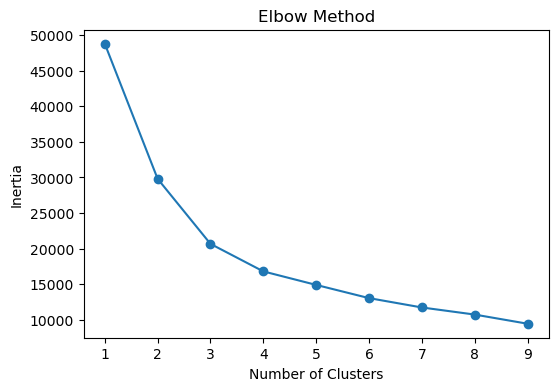

In [20]:
plt.figure(figsize=(6,4))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

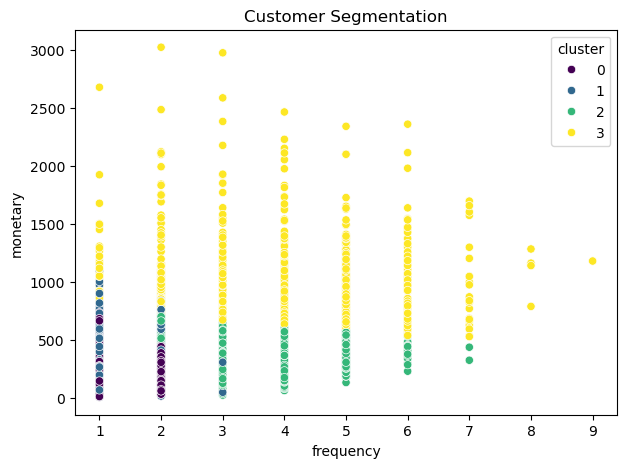

In [22]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=rfm,
    x="frequency",
    y="monetary",
    hue="cluster",
    palette="viridis"
)

plt.title("Customer Segmentation")

plt.show()

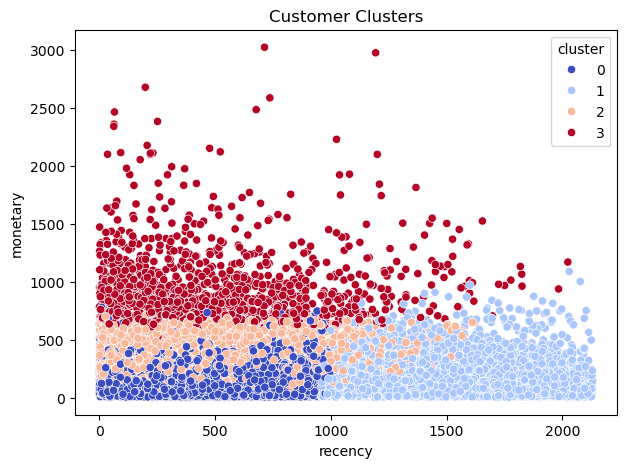

In [23]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=rfm,
    x="recency",
    y="monetary",
    hue="cluster",
    palette="coolwarm"
)

plt.title("Customer Clusters")

plt.show()

In [24]:
segment_map = {

0 : "High-value loyal customers",
1 : "At-risk customers",
2 : "New buyers",
3 : "Price-sensitive users"

}

rfm["segment"] = rfm["cluster"].map(segment_map)

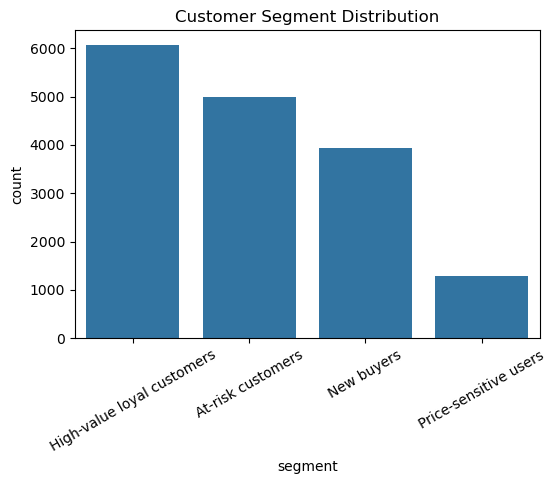

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x="segment", data=rfm)

plt.xticks(rotation=30)

plt.title("Customer Segment Distribution")

plt.show()

In [26]:
segment_output = rfm[[
    
    "customer_id",
    "recency",
    "frequency",
    "monetary",
    "RFM_score",
    "segment"

]]

segment_output.to_csv(
    "customer_segment_mapping.csv",
    index=False
)

print("Customer segment mapping file saved")

Customer segment mapping file saved
